In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
h = [0.2,0.4]
t = np.arange(0,1.2,h[0])
t2 = np.arange(0,2.4,h[1])




In [4]:
def solucao_exata(t):
    return (1/5)*t*np.exp(3*t) - (1/25)*np.exp(3*t) + (1/25)*np.exp(-2*t)

def f(y,t): 
    return t*np.exp(3*t) - 2*y

def g(y,t):
    return -(y+1)*(y+3)

def g_exata(t):
    return -3 + ((2)/(1+np.exp(-2*t)))


def adamBashforth2(y,t,h,fun):
    for i in range(1,len(t)-1):
        y[i+1] = y[i] + (h/2)*(((3*fun(y[i],t[i])) - fun(y[i-1],t[i-1])))
    return y

def adamBashforth3(y,t,h,fun):
    for i in range(2,len(t)-1):
        y[i+1] = y[i] + (h/12)* ((23*fun(y[i],t[i])) - 16*fun(y[i-1],t[i-1]) + 5*fun(y[i-2],t[i-2])) 
    return y


def adamBashforth4(y,t,h,fun):
    for i in range(3,len(t)-1):
        y[i+1] = y[i] + (h/24)* ((55*fun(y[i],t[i])) - 59*fun(y[i-1],t[i-1]) + 37*fun(y[i-2],t[i-2]) - 9*fun(y[i-3],t[i-3]))
    return y


def passo_rungeKutta(t_val, y_val, h, fun):
    k1 = fun(y_val, t_val)
    k2 = fun(y_val + (h/2)*k1, t_val + h/2)
    k3 = fun(y_val + (h/2)*k2, t_val + h/2)
    k4 = fun(y_val + h*k3, t_val + h)
    return y_val + (h/6) * (k1 + 2*k2 + 2*k3 + k4)


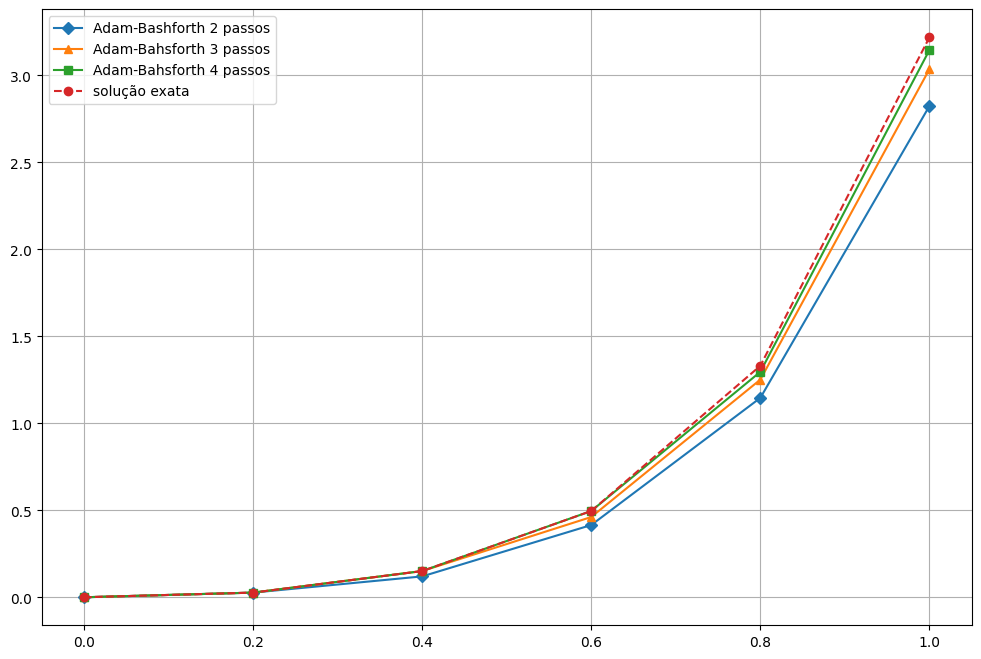

In [5]:
y = np.zeros(len(t))
y[0] = solucao_exata(0)
y[1] = solucao_exata(0.2) 
y = adamBashforth2(y,t,h[0],f)

y2 = np.zeros(len(t))
y2[0] = solucao_exata(0)
y2[1] = solucao_exata(0.2)
y2[2] = solucao_exata(0.4)
y2 = adamBashforth3(y2,t,h[0],f)


y3 = np.zeros(len(t))
y3[0] = solucao_exata(0)
y3[1] = solucao_exata(0.2)
y3[2] = solucao_exata(0.4)
y3[3] = solucao_exata(0.6)
y3 = adamBashforth4(y3,t,h[0],f)



plt.figure(figsize=(12,8)) 
plt.plot(t,y, marker = 'D' , label = 'Adam-Bashforth 2 passos')
plt.plot(t,y2, label = 'Adam-Bahsforth 3 passos',marker = '^')
plt.plot(t,y3,label = 'Adam-Bahsforth 4 passos',marker = 's')
plt.plot(t,solucao_exata(t),linestyle = '--', label = 'solução exata', marker = 'o')
plt.grid(True)
plt.legend() 
plt.show()


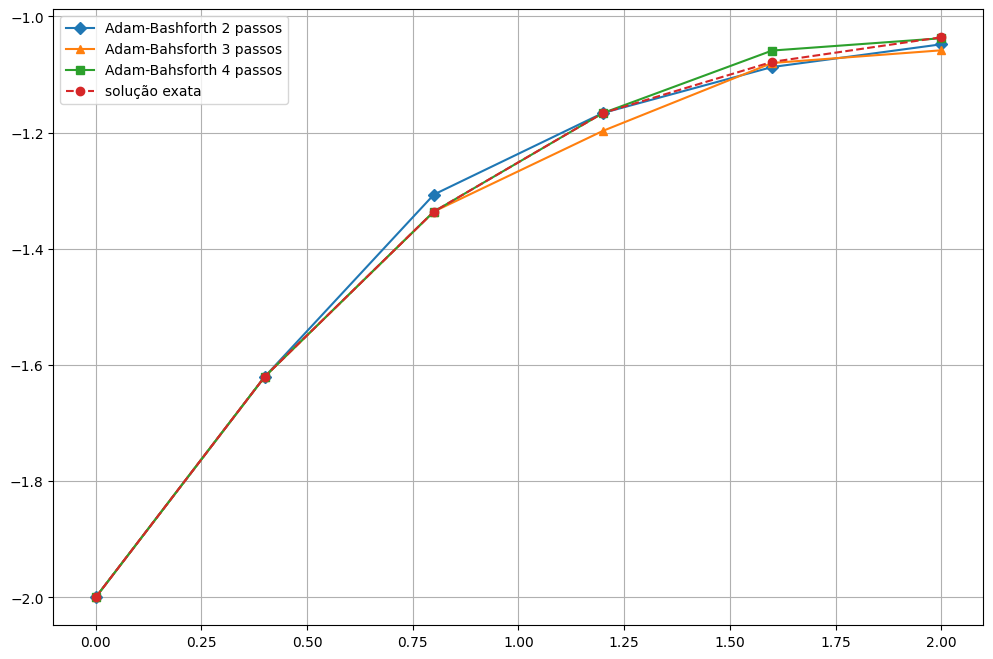

In [6]:
x = np.zeros(len(t2))
x[0] = g_exata(0)
x[1] = g_exata(0.4) 
x = adamBashforth2(x,t2,h[1],g)

x2 = np.zeros(len(t2))
x2[0] = g_exata(0)
x2[1] = g_exata(0.4)
x2[2] = g_exata(0.8)
x2 = adamBashforth3(x2,t2,h[1],g)


x3 = np.zeros(len(t2))
x3[0] = g_exata(0)
x3[1] = g_exata(0.4)
x3[2] = g_exata(0.8)
x3[3] = g_exata(1.2)
x3 = adamBashforth4(x3,t2,h[1],g)




plt.figure(figsize=(12,8)) 
plt.plot(t2,x, marker = 'D' , label = 'Adam-Bashforth 2 passos')
plt.plot(t2,x2, label = 'Adam-Bahsforth 3 passos',marker = '^')
plt.plot(t2,x3,label = 'Adam-Bahsforth 4 passos',marker = 's')
plt.plot(t2,g_exata(t2),linestyle = '--', label = 'solução exata', marker = 'o')
plt.grid(True)
plt.legend() 
plt.show()


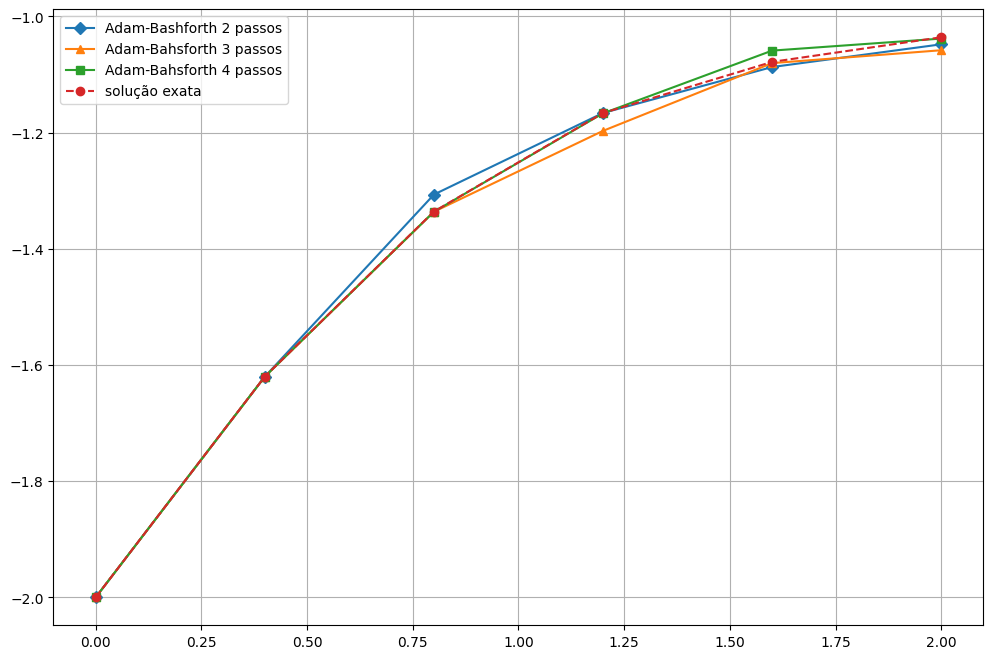

In [7]:
u = np.zeros(len(t2))
u[0] = -2
u[1] = passo_rungeKutta(t2,u[0],h[1],g)
u = adamBashforth2(u,t2,h[1],g)

u2 = np.zeros(len(t2))
u2[0] = -2
u2[1] = passo_rungeKutta(t2,u2[0],h[1],g)
u2[2] = passo_rungeKutta(t2,u2[1],h[1],g)
u2 = adamBashforth3(u2,t2,h[1],g)


u3 = np.zeros(len(t2))
u3[0] = -2
u3[1] = passo_rungeKutta(t2,u3[0],h[1],g)
u3[2] = passo_rungeKutta(t2,u3[1],h[1],g)
u3[3] = passo_rungeKutta(t2,u3[2],h[1],g)
u3 = adamBashforth4(u3,t2,h[1],g)




plt.figure(figsize=(12,8)) 
plt.plot(t2,u, marker = 'D' , label = 'Adam-Bashforth 2 passos')
plt.plot(t2,u2, label = 'Adam-Bahsforth 3 passos',marker = '^')
plt.plot(t2,u3,label = 'Adam-Bahsforth 4 passos',marker = 's')
plt.plot(t2,g_exata(t2),linestyle = '--', label = 'solução exata', marker = 'o')
plt.grid(True)
plt.legend() 
plt.show()


In [8]:
erro_ab2 = np.zeros(len(t2))
erro_ab2_rk = np.zeros(len(t2))
erro_ab3 = np.zeros(len(t2))
erro_ab3_rk = np.zeros(len(t2))
erro_ab4 = np.zeros(len(t2))
erro_ab4_rk = np.zeros(len(t2))

sol_exata = np.zeros(len(t2))
sol_exata = g_exata(t2)

for i in range(len(t2)): 
    erro_ab2[i] = np.abs(x[i] - sol_exata[i])
    erro_ab2_rk[i] = np.abs(u[i] - sol_exata[i])
    erro_ab3[i] = np.abs(x2[i] - sol_exata[i])
    erro_ab3_rk[i] = np.abs(u2[i] - sol_exata[i])
    erro_ab4[i] = np.abs(x3[i] - sol_exata[i])
    erro_ab4_rk[i] = np.abs(u3[i] - sol_exata[i])




In [10]:
dados = {
    'Tempo (t2)': t2,
    'Erro AB2': erro_ab2,
    'Erro AB2 (RK)': erro_ab2_rk,
    'Erro AB3': erro_ab3,
    'Erro AB3 (RK)': erro_ab3_rk,
    'Erro AB4': erro_ab4,
    'Erro AB4 (RK)': erro_ab4_rk
}


tabela_erros = pd.DataFrame(dados)
tabela_erros


,Tempo (t2),Erro AB2,Erro AB2 (RK),Erro AB3,Erro AB3 (RK),Erro AB4,Erro AB4 (RK)
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.4,0.000000,0.000092,0.000000,0.000092,0.000000,0.000092
2,0.8,0.029295,0.029245,0.000000,0.000324,0.000000,0.000324
3,1.2,0.000124,0.000102,0.030683,0.030714,0.000000,0.000542
4,1.6,0.008860,0.008874,0.001905,0.002115,0.019494,0.019401
5,2.0,0.012113,0.012119,0.022454,0.022323,0.001701,0.002268
